# Round 3 — Delta-1 Analysis

Analysis of the two delta-1 products in Round 3: `HYDROGEL_PACK` and
`VELVETFRUIT_EXTRACT`. VELVETFRUIT_EXTRACT is also the underlying of the 10
VEV vouchers — see `analysis_options.ipynb`.

See `DESIGN.md` for the notebook outline.

## A. Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import helpers

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "Data"))
OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "output"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRICE_FILES = [
    "prices_round_3_day_0.csv",
    "prices_round_3_day_1.csv",
    "prices_round_3_day_2.csv",
]
TRADE_FILES = [
    "trades_round_3_day_0.csv",
    "trades_round_3_day_1.csv",
    "trades_round_3_day_2.csv",
]

DELTA1_PRODUCTS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VISIBLE_LEVELS = 3
HORIZON = 10

In [3]:
prices_all = helpers.load_prices(DATA_DIR, PRICE_FILES)
trades_all = helpers.load_trades(DATA_DIR, TRADE_FILES)

prices = prices_all[prices_all["product"].isin(DELTA1_PRODUCTS)].copy()
trades = trades_all[trades_all["product"].isin(DELTA1_PRODUCTS)].copy()

book = helpers.build_book_features(prices)
trade_agg, raw_trades = helpers.build_trade_features(trades, book)
df = helpers.merge_book_and_trade(book, trade_agg)

print(f"book rows       : {len(book):>7,}")
print(f"trade agg rows  : {len(trade_agg):>7,}")
print(f"raw trade rows  : {len(raw_trades):>7,}")
print(f"merged df rows  : {len(df):>7,}")

book rows       :  60,000
trade agg rows  :   2,373
raw trade rows  :   2,382
merged df rows  :  60,000


### A.5 Data quality summary

In [4]:
qc = (df.groupby(["product", "day"])
        .agg(rows=("timestamp", "size"),
             nan_mid=("mid_price", lambda s: s.isna().sum()),
             zero_mid=("mid_price", lambda s: (s == 0).sum()))
        .reset_index())
display(qc)

bad_mask = df["mid_price"] == 0
print(f"zero-mid rows: {bad_mask.sum()}  ({100*bad_mask.mean():.3f}%)")
df_clean = df[~bad_mask].copy()

,product,day,rows,nan_mid,zero_mid
0,HYDROGEL_PACK,0,10000,0,0
1,HYDROGEL_PACK,1,10000,0,0
2,HYDROGEL_PACK,2,10000,0,0
3,VELVETFRUIT_EXTRACT,0,10000,0,0
4,VELVETFRUIT_EXTRACT,1,10000,0,0
5,VELVETFRUIT_EXTRACT,2,10000,0,0


zero-mid rows: 0  (0.000%)


## B. Cross-product overview

Both products plotted together across the three days to spot regime shifts
and coupling.

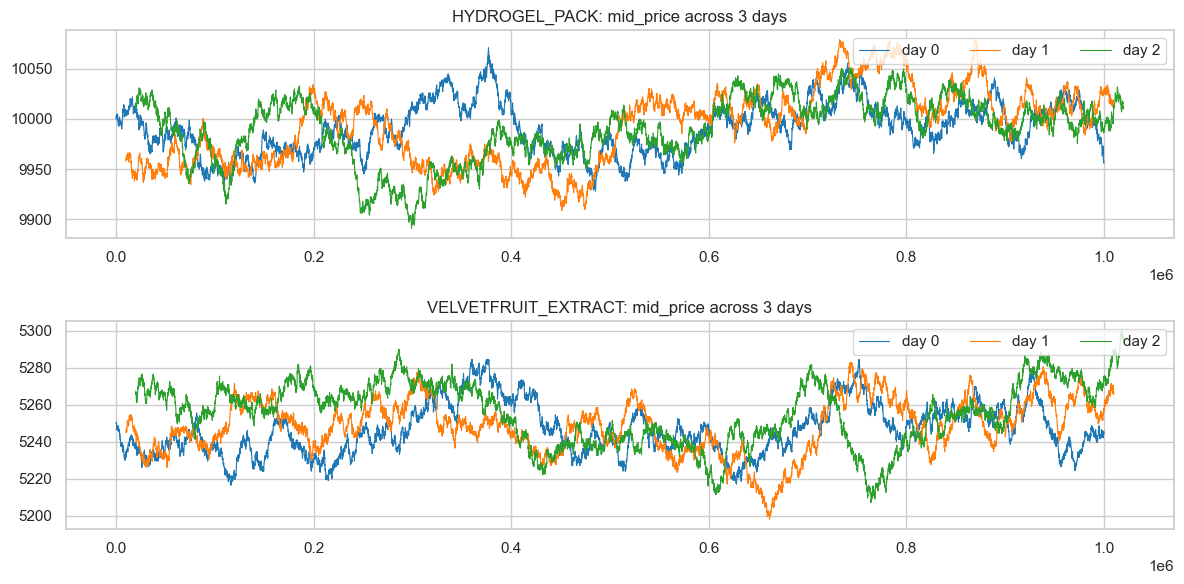

In [5]:
fig, axes = plt.subplots(len(DELTA1_PRODUCTS), 1,
                         figsize=(12, 3 * len(DELTA1_PRODUCTS)), sharex=False)
if len(DELTA1_PRODUCTS) == 1:
    axes = [axes]
for ax, prod in zip(axes, DELTA1_PRODUCTS):
    for d, color in zip(sorted(df_clean["day"].unique()),
                        sns.color_palette("tab10")):
        s = df_clean[(df_clean["product"] == prod) & (df_clean["day"] == d)]
        ax.plot(s["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
                s["mid_price"].to_numpy(), color=color, label=f"day {d}", lw=0.8)
    ax.set_title(f"{prod}: mid_price across 3 days")
    ax.legend(loc="upper right", ncol=3)
plt.tight_layout()
plt.show()

### B.3 Per-day OLS drift slope

In [6]:
rows = []
for prod in DELTA1_PRODUCTS:
    for d in sorted(df_clean["day"].unique()):
        s = df_clean[(df_clean["product"] == prod) & (df_clean["day"] == d)].sort_values("timestamp")
        if len(s) < 10:
            continue
        slope, intercept = np.polyfit(s["timestamp"].to_numpy(float),
                                      s["mid_price"].to_numpy(float), 1)
        rows.append({"product": prod, "day": d, "slope_per_tick": slope,
                     "intercept": intercept, "r_points": len(s)})
drift = pd.DataFrame(rows)
display(drift)

,product,day,slope_per_tick,intercept,r_points
0,HYDROGEL_PACK,0,0.000031,9975.297297,10000
1,HYDROGEL_PACK,1,0.000084,9949.870683,10000
2,HYDROGEL_PACK,2,0.000051,9963.979635,10000
3,VELVETFRUIT_EXTRACT,0,0.000013,5239.775550,10000
4,VELVETFRUIT_EXTRACT,1,0.000008,5244.595279,10000
5,VELVETFRUIT_EXTRACT,2,-0.000007,5258.947905,10000


### B.4 Tick-return distribution, autocorrelation, rolling volatility

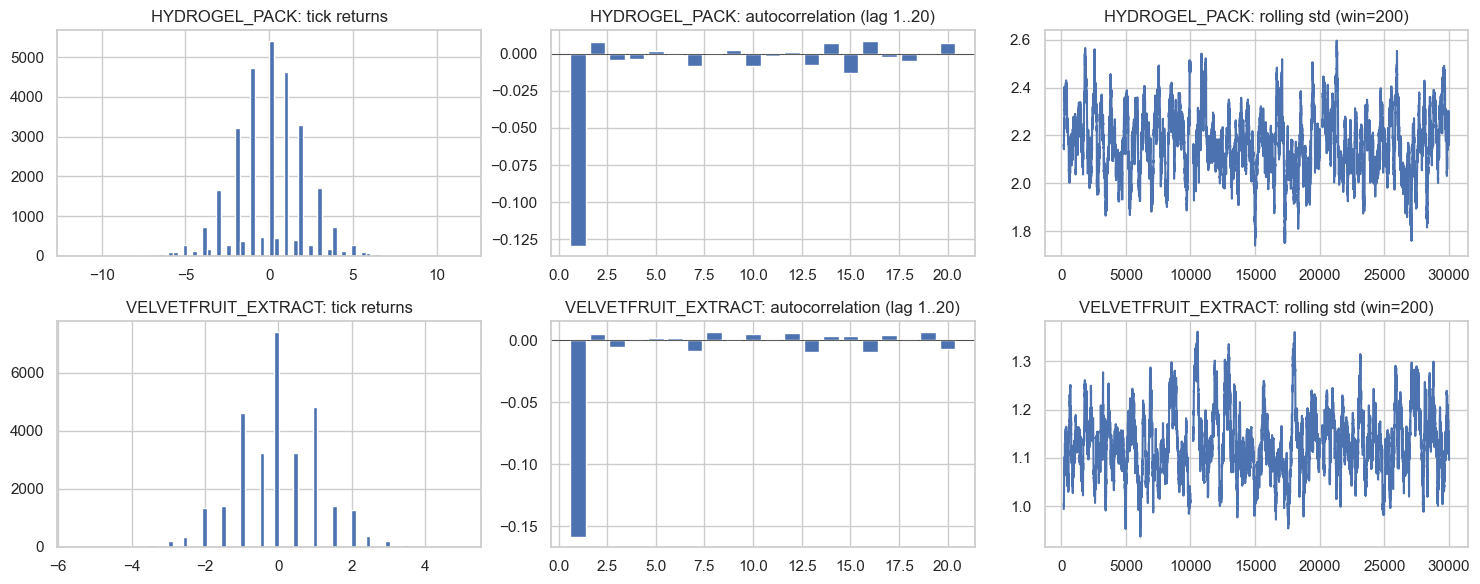

In [7]:
MAX_LAG = 20
ROLL_WIN = 200

fig, axes = plt.subplots(len(DELTA1_PRODUCTS), 3,
                         figsize=(15, 3 * len(DELTA1_PRODUCTS)))
if len(DELTA1_PRODUCTS) == 1:
    axes = axes.reshape(1, -1)

for row, prod in enumerate(DELTA1_PRODUCTS):
    s = df_clean[df_clean["product"] == prod].sort_values(["day", "timestamp"])
    rets = s.groupby("day")["mid_price"].diff()
    axes[row, 0].hist(rets.dropna(), bins=80)
    axes[row, 0].set_title(f"{prod}: tick returns")
    # autocorr
    acf = [rets.autocorr(lag) for lag in range(1, MAX_LAG + 1)]
    axes[row, 1].bar(range(1, MAX_LAG + 1), acf)
    axes[row, 1].axhline(0, color="k", lw=0.5)
    axes[row, 1].set_title(f"{prod}: autocorrelation (lag 1..{MAX_LAG})")
    # rolling vol
    rv = rets.rolling(ROLL_WIN).std()
    axes[row, 2].plot(rv.to_numpy())
    axes[row, 2].set_title(f"{prod}: rolling std (win={ROLL_WIN})")
plt.tight_layout()
plt.show()

### B.5 Cross-product tick-return correlation per day

In [8]:
rows = []
for d in sorted(df_clean["day"].unique()):
    pivot = (df_clean[df_clean["day"] == d]
             .pivot_table(index="timestamp", columns="product", values="mid_price")
             .sort_index())
    rets = pivot.diff().dropna()
    if rets.shape[1] < 2:
        continue
    rows.append({
        "day": d,
        "corr": helpers.safe_corr(rets[DELTA1_PRODUCTS[0]], rets[DELTA1_PRODUCTS[1]]),
        "n": len(rets),
    })
display(pd.DataFrame(rows))

,day,corr,n
0,0,0.011119,9999
1,1,0.012005,9999
2,2,-0.004981,9999


## C. Per-product drill-down

Each cell loops over both delta-1 products and emits one figure per product.

In [9]:
def describe_static_geometry(x, prod):
    summary = {
        "touch_spread_mean":    x["touch_spread"].mean(),
        "touch_spread_median":  x["touch_spread"].median(),
        "boundary_width_mean":  x["boundary_width"].mean(),
        "size_wall_width_mean": x["size_wall_width"].mean(),
        "rows":                 len(x),
    }
    return summary

geom_rows = []
for prod in DELTA1_PRODUCTS:
    x = df_clean[df_clean["product"] == prod]
    geom_rows.append({"product": prod, **describe_static_geometry(x, prod)})
display(pd.DataFrame(geom_rows))

,product,touch_spread_mean,touch_spread_median,boundary_width_mean,size_wall_width_mean,rows
0,HYDROGEL_PACK,15.720800,16.000000,20.980100,20.980100,30000
1,VELVETFRUIT_EXTRACT,4.988133,5.000000,6.250000,6.250000,30000


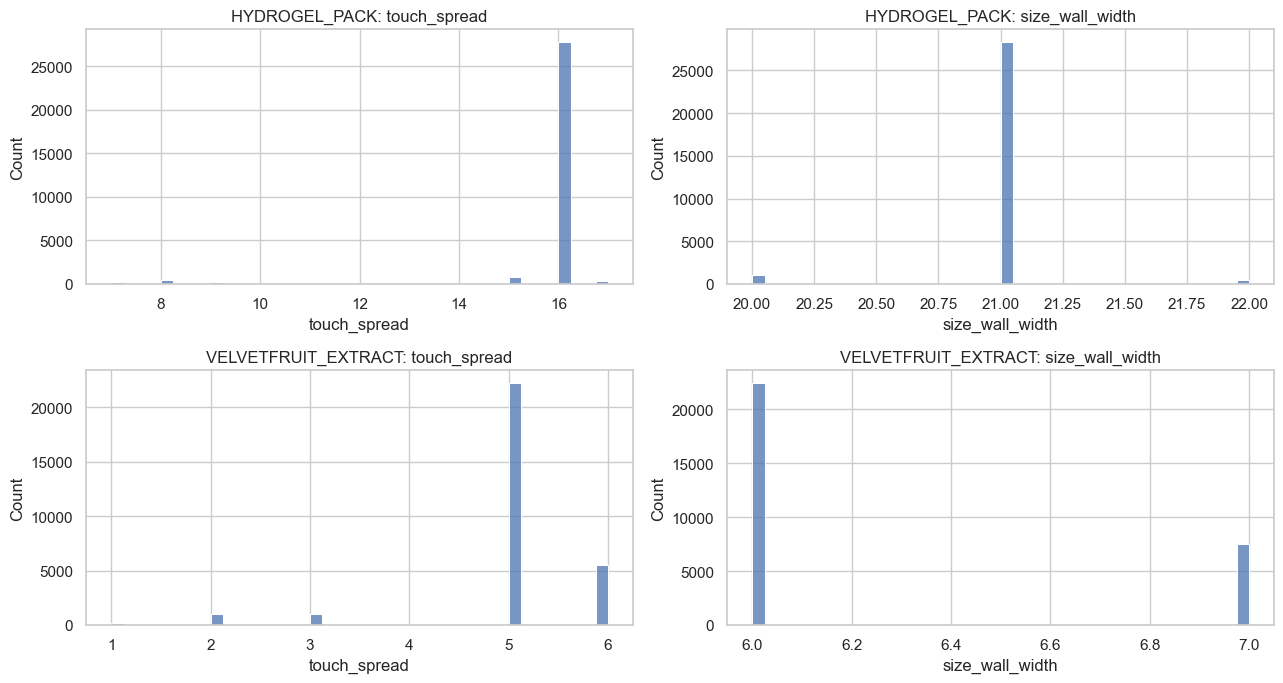

In [10]:
fig, axes = plt.subplots(len(DELTA1_PRODUCTS), 2,
                         figsize=(13, 3.5 * len(DELTA1_PRODUCTS)))
if len(DELTA1_PRODUCTS) == 1:
    axes = axes.reshape(1, -1)
for row, prod in enumerate(DELTA1_PRODUCTS):
    x = df_clean[df_clean["product"] == prod]
    sns.histplot(x["touch_spread"], bins=40, ax=axes[row, 0])
    axes[row, 0].set_title(f"{prod}: touch_spread")
    sns.histplot(x["size_wall_width"], bins=40, ax=axes[row, 1])
    axes[row, 1].set_title(f"{prod}: size_wall_width")
plt.tight_layout()
plt.show()

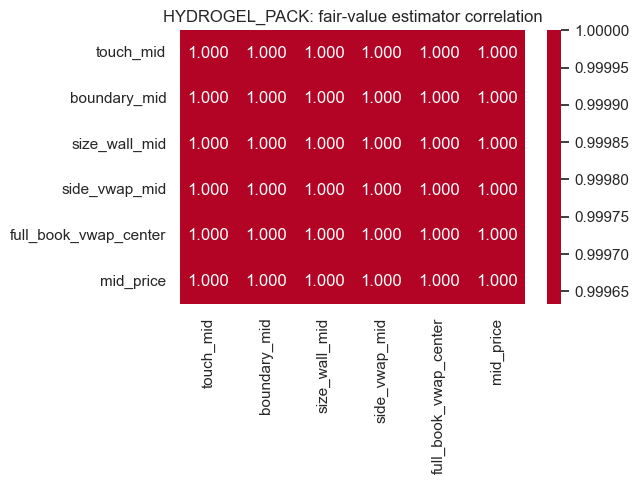

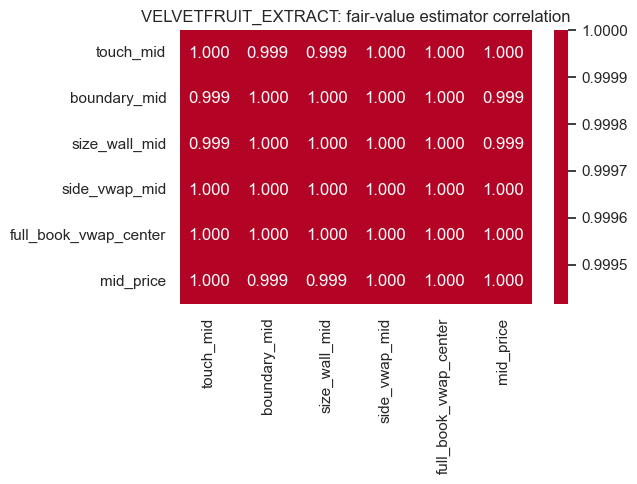

In [11]:
FAIR_VALUE_COLS = [
    "touch_mid", "boundary_mid", "size_wall_mid",
    "side_vwap_mid", "full_book_vwap_center", "mid_price",
]

for prod in DELTA1_PRODUCTS:
    x = df_clean[df_clean["product"] == prod]
    corr = x[FAIR_VALUE_COLS].corr()
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"{prod}: fair-value estimator correlation")
    plt.tight_layout()
    plt.show()

In [12]:
PREDICTOR_FEATURES = [
    "touch_spread", "boundary_width", "size_wall_width",
    "frontier_imbalance", "depth_imbalance", "size_wall_vol_imbalance",
    "boundary_mid_minus_touch_mid", "size_wall_mid_minus_touch_mid",
    "side_vwap_mid_minus_touch_mid", "full_book_vwap_center_minus_touch_mid",
    "mid_price_minus_touch_mid",
]
target_change = f"fwd_touch_mid_change_{HORIZON}"
target_dir    = f"fwd_direction_{HORIZON}"

pred_rows = []
for prod in DELTA1_PRODUCTS:
    x = df_clean[df_clean["product"] == prod]
    for feat in PREDICTOR_FEATURES:
        if feat not in x.columns:
            continue
        pred_rows.append({
            "product": prod,
            "feature": feat,
            "corr_with_fwd_change":    helpers.safe_corr(x[feat], x[target_change]),
            "corr_with_fwd_direction": helpers.safe_corr(x[feat], x[target_dir]),
        })
pred_df = (pd.DataFrame(pred_rows)
             .assign(abs_corr=lambda d: d["corr_with_fwd_change"].abs())
             .sort_values(["product", "abs_corr"], ascending=[True, False])
             .drop(columns="abs_corr"))
display(pred_df)

,product,feature,corr_with_fwd_change,corr_with_fwd_direction
9,HYDROGEL_PACK,full_book_vwap_center_minus_touch_mid,0.115721,0.085120
8,HYDROGEL_PACK,side_vwap_mid_minus_touch_mid,0.113352,0.083747
4,HYDROGEL_PACK,depth_imbalance,-0.111205,-0.080032
6,HYDROGEL_PACK,boundary_mid_minus_touch_mid,0.111117,0.082338
7,HYDROGEL_PACK,size_wall_mid_minus_touch_mid,0.111117,0.082338
3,HYDROGEL_PACK,frontier_imbalance,0.098358,0.072957
1,HYDROGEL_PACK,boundary_width,-0.030247,-0.017749
2,HYDROGEL_PACK,size_wall_width,-0.030247,-0.017749
0,HYDROGEL_PACK,touch_spread,-0.017699,-0.010308
5,HYDROGEL_PACK,size_wall_vol_imbalance,NaN,NaN


In [13]:
rows = []
for prod in DELTA1_PRODUCTS:
    t = raw_trades[raw_trades["product"] == prod].copy()
    if "trade_location" not in t.columns:
        continue
    loc = t["trade_location"].value_counts(dropna=False).to_frame("count")
    loc["fraction"] = loc["count"] / loc["count"].sum()
    loc["product"] = prod
    rows.append(loc.reset_index().rename(columns={"index": "trade_location"}))
if rows:
    display(pd.concat(rows, ignore_index=True))
else:
    print("No trade_location column — check build_trade_features output.")

,trade_location,count,fraction,product
0,at_or_above_ask_touch,524,0.518812,HYDROGEL_PACK
1,at_or_below_bid_touch,486,0.481188,HYDROGEL_PACK
2,at_or_above_ask_touch,781,0.569242,VELVETFRUIT_EXTRACT
3,at_or_below_bid_touch,591,0.430758,VELVETFRUIT_EXTRACT


In [14]:
next_sign_rows = []
for prod in DELTA1_PRODUCTS:
    x = df_clean[df_clean["product"] == prod]
    if "next_trade_sign_proxy" not in x.columns:
        continue
    for feat in ["frontier_imbalance", "depth_imbalance", "size_wall_vol_imbalance",
                 "touch_spread", "boundary_width"]:
        next_sign_rows.append({
            "product": prod,
            "feature": feat,
            "corr_with_next_trade_sign": helpers.safe_corr(x[feat], x["next_trade_sign_proxy"]),
        })
next_sign_df = pd.DataFrame(next_sign_rows)
display(next_sign_df)

,product,feature,corr_with_next_trade_sign
0,HYDROGEL_PACK,frontier_imbalance,0.010016
1,HYDROGEL_PACK,depth_imbalance,-0.030414
2,HYDROGEL_PACK,size_wall_vol_imbalance,NaN
3,HYDROGEL_PACK,touch_spread,0.043496
4,HYDROGEL_PACK,boundary_width,-0.033613
5,VELVETFRUIT_EXTRACT,frontier_imbalance,-0.006170
6,VELVETFRUIT_EXTRACT,depth_imbalance,0.014543
7,VELVETFRUIT_EXTRACT,size_wall_vol_imbalance,0.004085
8,VELVETFRUIT_EXTRACT,touch_spread,0.039106
9,VELVETFRUIT_EXTRACT,boundary_width,0.013709


## D. VELVETFRUIT_EXTRACT — underlying of vouchers

`VELVETFRUIT_EXTRACT` is the underlying of the 10 VEV vouchers. Its realized
volatility directly feeds the options book — see `analysis_options.ipynb`.

,day,timestamp,rv_100,rv_500,rv_2000
count,30000.000000,30000.000000,29700.000000,28500.000000,24000.000000
mean,1.000000,499950.000000,1.129765,1.131913,1.130663
std,0.816510,288679.944524,0.096520,0.043998,0.020986
min,0.000000,0.000000,0.825402,1.020040,1.074990
25%,0.000000,249975.000000,1.061683,1.100633,1.114291
50%,1.000000,499950.000000,1.127301,1.127033,1.130030
75%,2.000000,749925.000000,1.192358,1.158508,1.141697
max,2.000000,999900.000000,1.462701,1.280608,1.189720


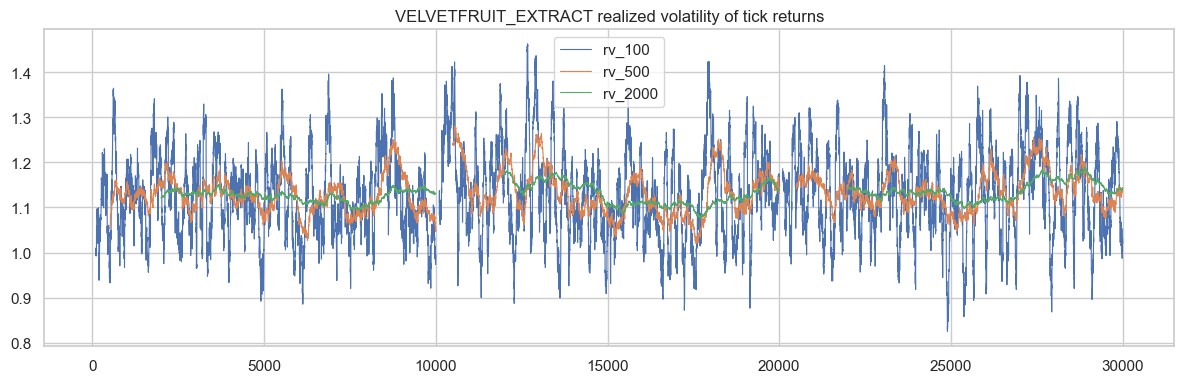

In [15]:
vev = df_clean[df_clean["product"] == "VELVETFRUIT_EXTRACT"].sort_values(["day", "timestamp"]).copy()
vev["ret"] = vev.groupby("day")["mid_price"].diff()

rv_frames = []
for win in (100, 500, 2000):
    rv = vev.groupby("day")["ret"].transform(lambda s: s.rolling(win).std())
    rv_frames.append(rv.rename(f"rv_{win}"))
rv_df = pd.concat([vev[["day", "timestamp"]].reset_index(drop=True)] +
                  [f.reset_index(drop=True) for f in rv_frames], axis=1)
display(rv_df.describe())

fig, ax = plt.subplots(figsize=(12, 4))
for col in [f"rv_{w}" for w in (100, 500, 2000)]:
    ax.plot(rv_df[col].to_numpy(), label=col, lw=0.8)
ax.set_title("VELVETFRUIT_EXTRACT realized volatility of tick returns")
ax.legend()
plt.tight_layout()
plt.show()

## E. Artifact exports

In [16]:
# delta1_feature_summary.csv
summary_rows = []
for prod in DELTA1_PRODUCTS:
    x = df_clean[df_clean["product"] == prod]
    summary_rows.append({
        "product": prod,
        "rows": len(x),
        "touch_spread_mean": x["touch_spread"].mean(),
        "touch_spread_median": x["touch_spread"].median(),
        "boundary_width_mean": x["boundary_width"].mean(),
        "size_wall_width_mean": x["size_wall_width"].mean(),
        "mean_mid_price": x["mid_price"].mean(),
        "per_day_drift_slope_mean": (drift[drift["product"] == prod]["slope_per_tick"].mean()
                                      if not drift.empty else float("nan")),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "delta1_feature_summary.csv"), index=False)

# delta1_predictor_ranking.csv
ranking = pred_df.merge(next_sign_df, on=["product", "feature"], how="outer")
ranking.to_csv(os.path.join(OUTPUT_DIR, "delta1_predictor_ranking.csv"), index=False)

# velvetfruit_realized_vol.csv
rv_df.to_csv(os.path.join(OUTPUT_DIR, "velvetfruit_realized_vol.csv"), index=False)

for name in ["delta1_feature_summary.csv",
             "delta1_predictor_ranking.csv",
             "velvetfruit_realized_vol.csv"]:
    path = os.path.join(OUTPUT_DIR, name)
    print(f"{name:40s} {os.path.getsize(path):>8,d} bytes")

delta1_feature_summary.csv                    312 bytes
delta1_predictor_ranking.csv                1,964 bytes
velvetfruit_realized_vol.csv             1,816,252 bytes


### Next: `analysis_options.ipynb`

The options notebook reuses `VELVETFRUIT_EXTRACT` as its underlying and pulls
realized vol context from `output/velvetfruit_realized_vol.csv`.